In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import OneHotEncoder


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
employee_DataFrame = pd.read_csv('/content/drive/MyDrive/ML/Lab_3/shopping_trends_updated.csv')

In [12]:
# Целевая переменная: пол (Male/Female)
y = employee_DataFrame['Gender']

# Исходные признаки
X = employee_DataFrame[['Age', 'Category', 'Purchase Amount (USD)', 'Size', 'Color']]

# Список категориальных столбцов для кодирования
list_to_encode = ['Category', 'Size', 'Color']

# OneHotEncoder – один на все категориальные признаки
encoder = OneHotEncoder(sparse_output=False)
# Преобразуем категориальные признаки в бинарные (0/1) через OneHotEncoder.
encoded = encoder.fit_transform(X[list_to_encode])

# Преобразуем результат в DataFrame с понятными названиями столбцов
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(list_to_encode))

# Удаляем исходные категориальные столбцы и добавляем закодированные
X = X.drop(columns=list_to_encode).join(encoded_df)

print(X)

      Age  Purchase Amount (USD)  Category_Accessories  Category_Clothing  \
0      55                     53                   0.0                1.0   
1      19                     64                   0.0                1.0   
2      50                     73                   0.0                1.0   
3      21                     90                   0.0                0.0   
4      45                     49                   0.0                1.0   
...   ...                    ...                   ...                ...   
3895   40                     28                   0.0                1.0   
3896   52                     49                   1.0                0.0   
3897   46                     33                   1.0                0.0   
3898   44                     77                   0.0                0.0   
3899   52                     81                   1.0                0.0   

      Category_Footwear  Category_Outerwear  Size_L  Size_M  Size_S  Size_X

In [14]:
# Делим выборку: 80% – обучение, 20% – тест (фиксируем seed для повторяемости)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y_train)


247       Male
2591      Male
1822      Male
3483    Female
2771    Female
         ...  
1130      Male
1294      Male
860       Male
3507    Female
3174    Female
Name: Gender, Length: 3120, dtype: object


#### 1.  Выбрать подходящую таблицу данных. Построить и визуализировать дерево решений.

In [17]:
from sklearn import tree # модуль для работы с деревьями решений.
from sklearn import metrics # модуль для расчёта метрик качества (точность, и т.д.).
import graphviz # библиотека для визуализации дерева
set_depth = 3 # максимальная глубина дерева

Accuracy =  0.7076923076923077


[Text(0.5, 0.875, 'x[0] <= 52.5\ngini = 0.44\nsamples = 3120\nvalue = [1020, 2100]'),
 Text(0.25, 0.625, 'x[0] <= 42.5\ngini = 0.449\nsamples = 2056\nvalue = [701, 1355]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[7] <= 0.5\ngini = 0.438\nsamples = 1478\nvalue = [478, 1000]'),
 Text(0.0625, 0.125, 'gini = 0.42\nsamples = 809\nvalue = [243, 566]'),
 Text(0.1875, 0.125, 'gini = 0.456\nsamples = 669\nvalue = [235.0, 434.0]'),
 Text(0.375, 0.375, 'x[6] <= 0.5\ngini = 0.474\nsamples = 578\nvalue = [223.0, 355.0]'),
 Text(0.3125, 0.125, 'gini = 0.457\nsamples = 425\nvalue = [150, 275]'),
 Text(0.4375, 0.125, 'gini = 0.499\nsamples = 153\nvalue = [73, 80]'),
 Text(0.75, 0.625, 'x[0] <= 54.5\ngini = 0.42\nsamples = 1064\nvalue = [319, 745]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[34] <= 0.5\ngini = 0.354\nsamples = 126\nvalue = [29, 97]'),
 Text(0.5625, 0.125, 'gini = 0.332\nsamples = 119\nvalue = [25, 94]'),
 Text(0.6875, 0.125, 'gini = 0.49\nsamples = 7\nvalue = [

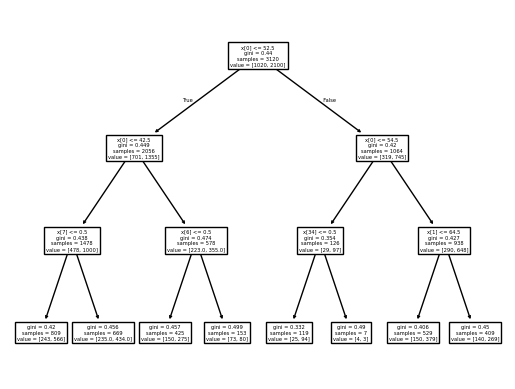

In [18]:
# Создание классификатора дерева
clf = tree.DecisionTreeClassifier(max_depth=set_depth)
# Обучение дерева
clf = clf.fit(X_train, y_train)
# Применение обученного дерева к тестовым данным
predictions = clf.predict(X_test)
# Доля правильных ответов
print(f'Accuracy = ', metrics.accuracy_score(y_test, predictions))
# Визуализиация древа
tree.plot_tree(clf)

#### 2. Применить метод градиентного бустинга. Вычислить значимость переменных. Выдать список построенных деревьев.

In [20]:
# Пункт 2: градиентный бустинг (Gradient Boosting)

# класс градиентного бустинга
from sklearn.ensemble import GradientBoostingClassifier
# инструмент для графиков частичной зависимости
from sklearn.inspection import PartialDependenceDisplay


Accuracy =  0.7051282051282052


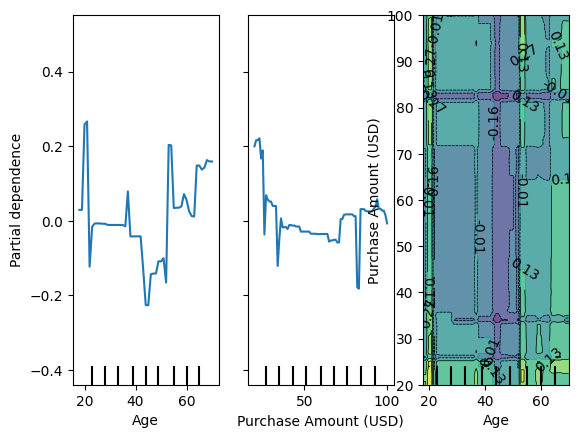

In [28]:
# классификатор на основе градиентного бустинга
# max_depth=set_depth – глубина каждого дерева (3 уровня)
# n_estimators=250 – количество деревьев в ансамбле
# learning_rate=0.02 – шаг градиентного спуска
clf = GradientBoostingClassifier(max_depth=set_depth, n_estimators=250, learning_rate=0.02)
# Обучение модели на трен. данных
clf = clf.fit(X_train, y_train)
# Предсказание меток для тестовой выборки
predictions = clf.predict(X_test)
# Точность данных (доля правильных ответов)
print(f'Accuracy = ', metrics.accuracy_score(y_test, predictions))

# Строит графики частичной зависимости
PartialDependenceDisplay.from_estimator(clf, X, [0, 1, (0, 1)])

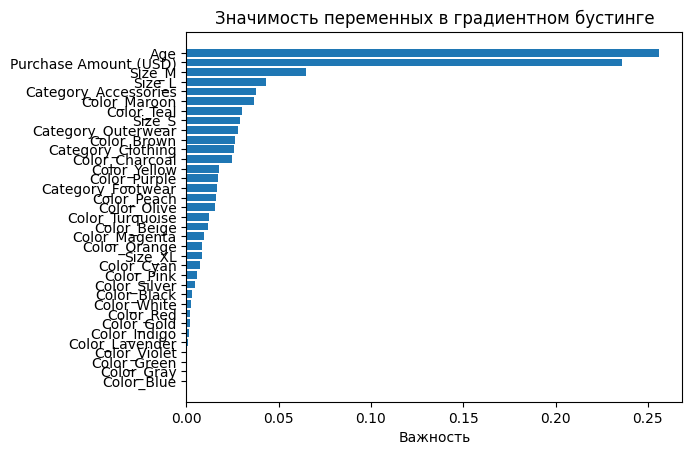

In [33]:
import matplotlib.pyplot as plt
import numpy as np
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)
plt.barh(np.array(X.columns)[sorted_idx], importances[sorted_idx])
plt.xlabel("Важность")
plt.title("Значимость переменных в градиентном бустинге")
plt.show()

In [34]:
print("Первые 3 дерева из ансамбля:")
for i in range(3):
    print(clf.estimators_[i])
print(f"Тип деревьев: {type(clf.estimators_[0][0])}")
print(f"Форма массива estimators_: {clf.estimators_.shape}")

# clf.estimators_ # массив содержащий в себе все обученные деревья

Первые 3 дерева из ансамбля:
[DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                       random_state=RandomState(MT19937) at 0x7F664D35F540)]
[DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                       random_state=RandomState(MT19937) at 0x7F664D35F540)]
[DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                       random_state=RandomState(MT19937) at 0x7F664D35F540)]
Тип деревьев: <class 'sklearn.tree._classes.DecisionTreeRegressor'>
Форма массива estimators_: (250, 1)


#### 3. Построить зависимость качества решения (на обучении и скользящем контроле) от числа вершин дерева.

In [44]:
from sklearn.tree import DecisionTreeClassifier # одиночное дерево решений
from sklearn.model_selection import cross_val_score # кросс-валидация
import matplotlib.pyplot as plt  # метрика точности
from sklearn.metrics import accuracy_score # построение графиков

In [57]:
max_leaf_nodes_range = range(2, 30) # диапазон листьев
train_scores = [] # точность на обучающей выборке
test_scores = [] # точность на тестовой выборке
cv_scores = []  # средняя точность по кросс-валидации (5 блоков)

In [58]:
for leaf_nodes in max_leaf_nodes_range:
    dt = DecisionTreeClassifier(max_leaf_nodes=leaf_nodes, random_state=42) # создаёт дерево n по счёту
    dt.fit(X_train, y_train) # дерево обучается
    train_scores.append(accuracy_score(y_train, dt.predict(X_train))) # рассчёт точности на обучающейся выборке
    test_scores.append(accuracy_score(y_test, dt.predict(X_test))) # рассчёт точности на тестовой выборке
    cv_scores.append(cross_val_score(dt, X, y, cv=5).mean()) # расчёт средняя точность по 5 выборкам

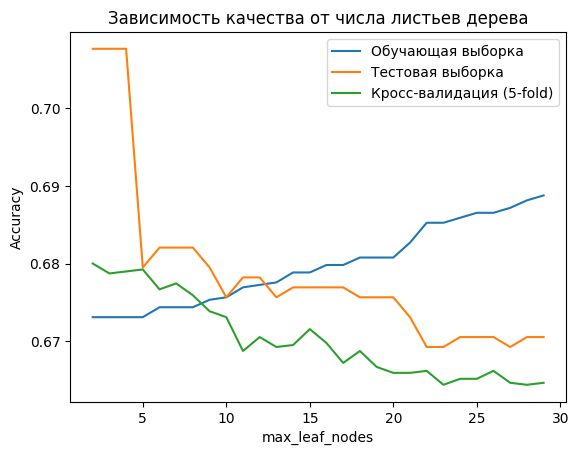

In [59]:
plt.plot(max_leaf_nodes_range, train_scores, label='Обучающая выборка')
plt.plot(max_leaf_nodes_range, test_scores, label='Тестовая выборка')
plt.plot(max_leaf_nodes_range, cv_scores, label='Кросс-валидация (5-fold)')
plt.xlabel('max_leaf_nodes')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Зависимость качества от числа листьев дерева')
plt.show()

* *Обучающая выборка* :
При увеличении max_leaf_nodes_range (число листьев) обучающая точность монотонно растёт, по причине того, что дерево становится сложнее и может точнее запоминать обучающие данные

* *Тестовая выьорка* : Точность сначала растёт (модель учится полезным закономерностям) , а затем после некоторого оптимального числа листьев , стабилизируется и снижается - Это признак переобучения

#### 4. Для метода градиентного бустинга построить зависимость качества решения (на обучении и скользящем контроле) от числа деревьев.Для разной глубины дерева нужно построить несколько зависимостей качества от числа деревьев, чтобы найти оптимальную комбинацию этих параметров.


In [66]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [67]:
max_trees = 100 # максимальное кол-во деревьев
depths = [1, 5, 10]  # разные глубины деревьев

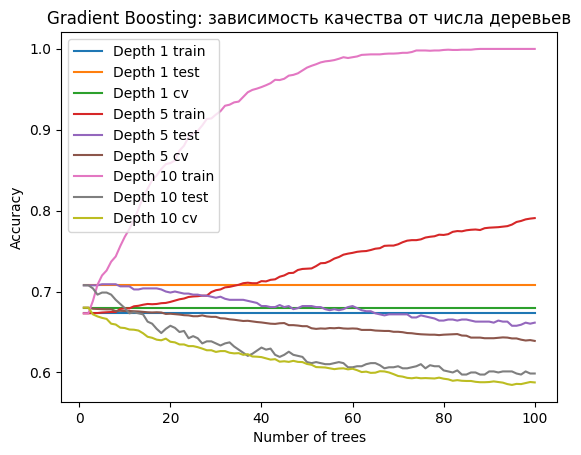

In [68]:
for depth in depths:
    train_scores = [] # точность на обучающей выборке
    test_scores = [] # точность на тестовой выборке
    cv_scores = [] # средняя точность на кросс-валидации (5 блоков)
    for n in range(1, max_trees+1):
        # max_depth -ограничение по глубине,n_estimators - текущее кол-во деревьев в ансамбле , random_state - сид
        gb = GradientBoostingClassifier(max_depth=depth, n_estimators=n, random_state=42)
        gb.fit(X_train, y_train) # обучение
        train_scores.append(accuracy_score(y_train, gb.predict(X_train))) # добавляю точность к обучающей выборке
        test_scores.append(accuracy_score(y_test, gb.predict(X_test))) # добавляю точность к тестовой выборке
        cv_scores.append(cross_val_score(gb, X, y, cv=5).mean()) # расчёт средней точсности по 5-блочной на всех данных Х, у
    # график для текущей глубины
    plt.plot(range(1, max_trees+1), train_scores, label=f'Depth {depth} train')
    plt.plot(range(1, max_trees+1), test_scores, label=f'Depth {depth} test')
    plt.plot(range(1, max_trees+1), cv_scores, label=f'Depth {depth} cv')
plt.xlabel('Number of trees')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Gradient Boosting: зависимость качества от числа деревьев')
plt.show()

#### 5. Выполнить предыдущий пункт для случайного леса. Сравнить оценку out-of-bag с оценкой по кроссвалидации.

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

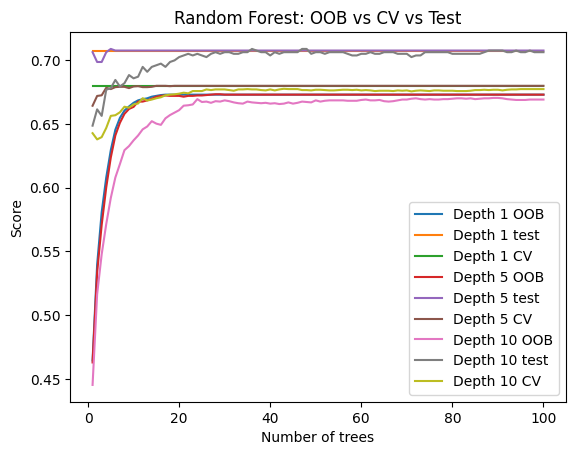

Сравнение OOB и CV для оптимального леса:
OOB score: 0.6692
Cross-validation mean: 0.6774


In [70]:
for depth in depths:
    oob_scores = [] # список для OOB-оценок
    cv_scores = [] # список для средней точности по кросс-валидации
    test_scores = [] # список для точности на тестовой выборке
    for n in range(1, max_trees+1):
        rf = RandomForestClassifier(max_depth=depth, n_estimators=n, oob_score=True, random_state=42)
        rf.fit(X_train, y_train)
        oob_scores.append(rf.oob_score_) # OOB-оценка
        test_scores.append(accuracy_score(y_test, rf.predict(X_test)))
        cv_scores.append(cross_val_score(rf, X, y, cv=5).mean())

    plt.plot(range(1, max_trees+1), oob_scores, label=f'Depth {depth} OOB')
    plt.plot(range(1, max_trees+1), test_scores, label=f'Depth {depth} test')
    plt.plot(range(1, max_trees+1), cv_scores, label=f'Depth {depth} CV')
plt.xlabel('Number of trees')
plt.ylabel('Score')
plt.legend()
plt.title('Random Forest: OOB vs CV vs Test')
plt.show()

print("Сравнение OOB и CV для оптимального леса:")
print(f"OOB score: {rf.oob_score_:.4f}")
print(f"Cross-validation mean: {cross_val_score(rf, X, y, cv=5).mean():.4f}")